# Notebook 1 - Bibliometric Analysis

This notebook contains bibliometric analysis of current publications sourced from Scopus + WoS. The purpose of this analyses is to assess the distribution of publications at the intersection of degenerative neurological diseases and active transportation (e.g. walking, cycling).

Analyses to include: 
* Publications over time
* Most productive countries

## Referenced material: 
1. [Colab code scopus example](https://colab.research.google.com/drive/1yHiMMZIKa-RrarXbPB9ca0gLN9YvvtPU?usp=sharing#scrollTo=Xl-I-RZf_BoK)
2. [Implementation and practical guide pdf](https://bedujournal.com/files/19/PUB/MA/677430ee6a7f9/M8041-234221.pdfs)

Note that rate of publication differs from discipline to discipline. Since this topic is concerned with neuroscience, publication volumes are expected to be lower.

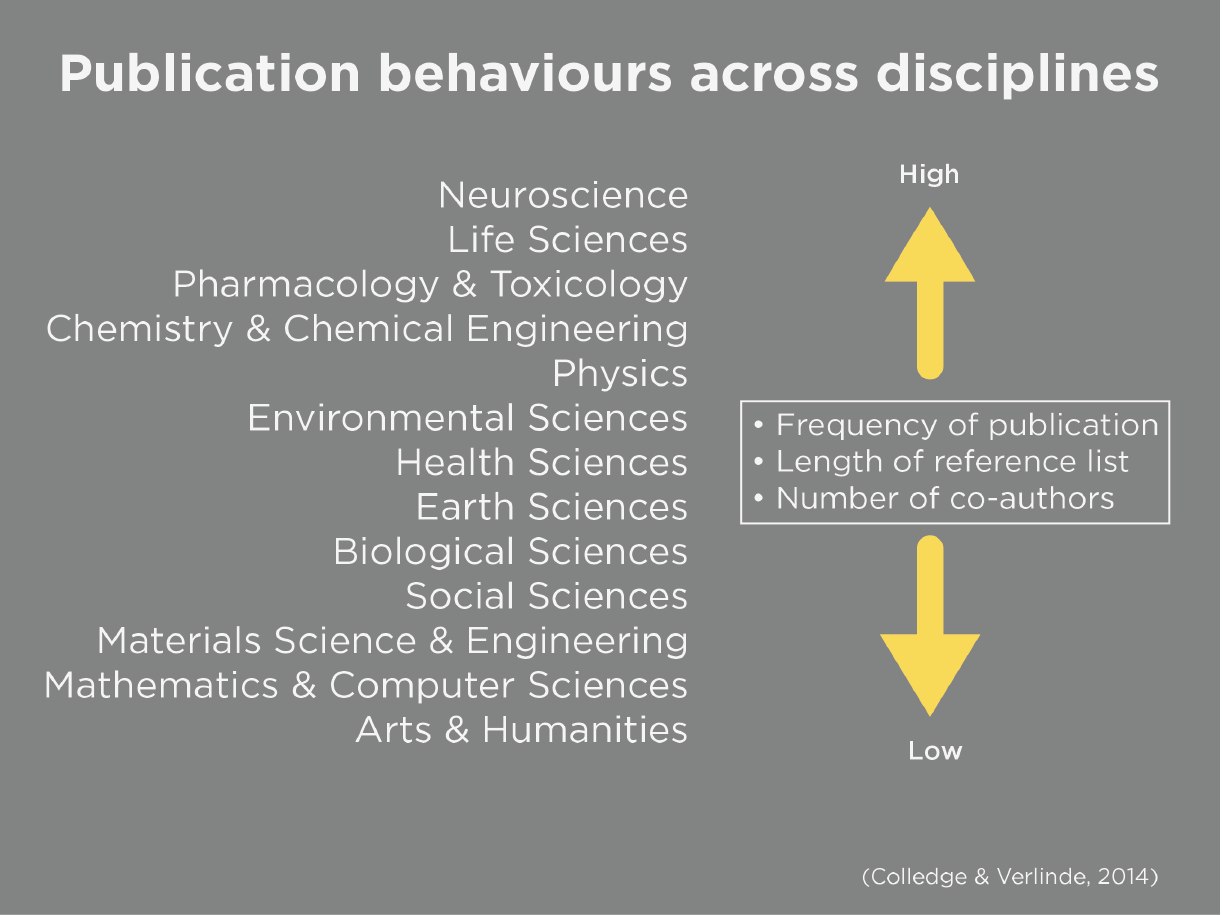

# 1. Initial imports

## 1.1 Package import

In [1]:
!pip install --upgrade nbformat


In [2]:
import pybibx
# Required packages
import numpy as np
import pandas as pd
import textwrap
import isoduration

from tabulate import tabulate
from prettytable import PrettyTable
from pybibx.base import pbx_probe

## 1.2 Citation Import

Source: Scopus
Query: "cycling" AND "dementia"

This review is meant to capture general academic interest, thus filtering criteria includes reviews and conference papers. 

Removed: 
* Editorials
* Notes
* Short surveys

In [3]:
path = 'scopus-data/cycling-and-dementia_20-05-2026_02.csv'

bibfile = pbx_probe(file_bib=path, db='scopus', del_duplicated=True)

A Total of 219 Documents were Found ( 220 Documents and 1 Duplicates )

Article = 161
Book chapter = 5
Conference paper = 8
Conference review = 1
Review = 44


In [4]:
# Citation health
health = bibfile.health_bib()

health

,Entries,Completeness (%),Number of Docs
0,Sources,100.00%,219
1,Abstracts,97.26%,213
2,Affiliation,100.00%,219
3,Author(s),99.54%,218
4,DOI,94.06%,206
5,Keywords - Authors,76.71%,168
6,Keywords - Plus,92.69%,203
7,References,95.89%,210
8,Year,100.00%,219


# 2. Citation analysis

Analysis is intended to reveal information about the current state of research. 

Key questions:
1. What are the current trends in volume of publications?
2. What are the most commonly occuring topics?
3. What are the key publications in this field?


In [10]:
# Exploratory report

eda = bibfile.eda_bib()

eda

,Main Information,Results
0,Timespan,1987-2026
1,Total Number of Countries,42
2,Total Number of Institutions,542
3,Total Number of Sources,175
4,Total Number of References,41265
5,Total Number of Languages,6
6,--english (# of docs),211
7,--french (# of docs),1
8,--german (# of docs),4
9,--japanese (# of docs),1


## 2.1 Publication and citation volume metrics

1. Dcouments by year
2. Documents by country
3. Most cited sources

In [11]:
# Publications by year
bibfile.plot_bars(view='notebook', statistic='dpy')

In [ ]:
#### Countries per publication

# Assuming this is done by individual author affiliation since there are more documents "USA" than in the entire imported citation list
bibfile.plot_bars(view='notebook', statistic='cpd')

In [38]:
bibfile.plot_top_refs(view = 'notebook', topn = 10, font_size = 10, use_ref_id = False, date_start = None, date_end = None)

In [39]:
bibfile.plot_count_y_per_x(view = 'notebook', rmv_unknowns = True, x = 'cout', y = 'aut', topn_x = 5, topn_y = 5, text_font_size = 12, x_angle = -90)

## 2.2 Keywords and topics 

1. Most commonly used keywords
2. Most commonly used words in document titles
3. Most commonly occuring words in abstracts

In [ ]:
wordsn = 100 # words to include in wordclouds

### 2.2.1 Most commonly used keywords

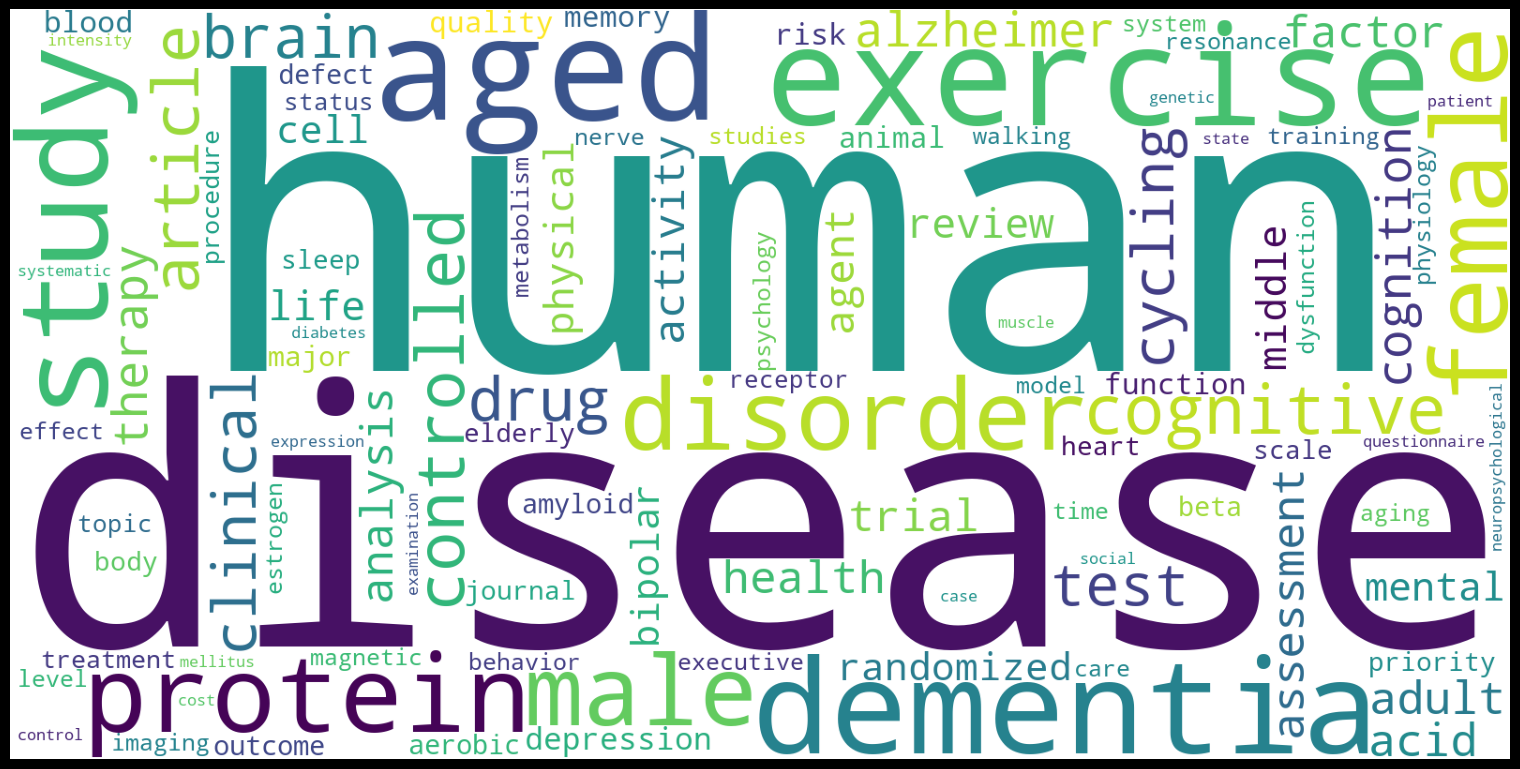

In [23]:
#### Most common keywords

# Wordcloud entry types:
#   'abs' = abstract
#   'title' = document title
#   'kwa' = author keywords
#   'kwp' = keywords plus (assigned by publisher)

bibfile.word_cloud_plot(entry = 'kwp', size_x = 15, size_y = 10, wordsn = wordsn, rmv_custom_words = [])

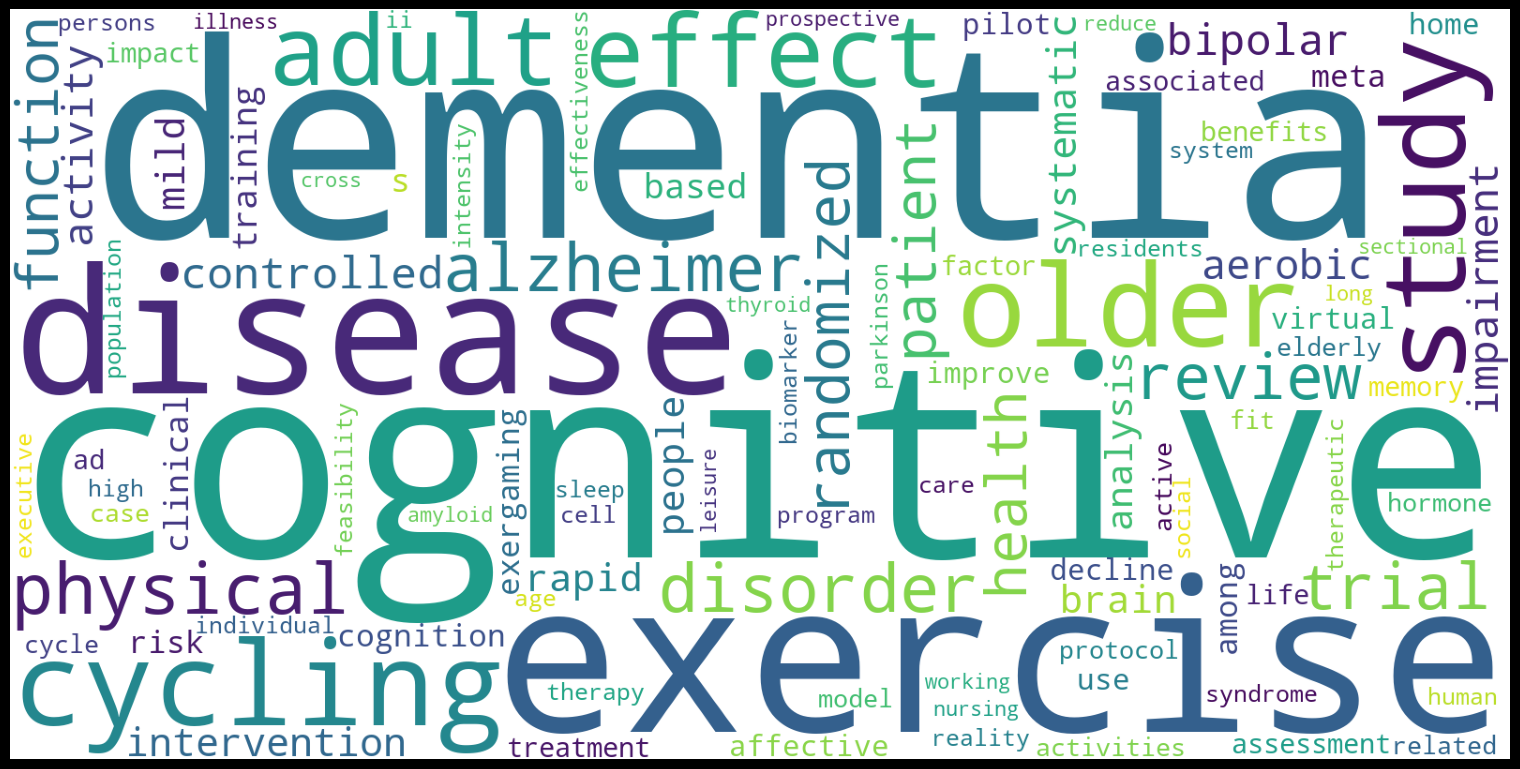

In [24]:
#### Most commonly used words in titles

bibfile.word_cloud_plot(entry = 'title', size_x = 15, size_y = 10, wordsn = wordsn, rmv_custom_words = [])

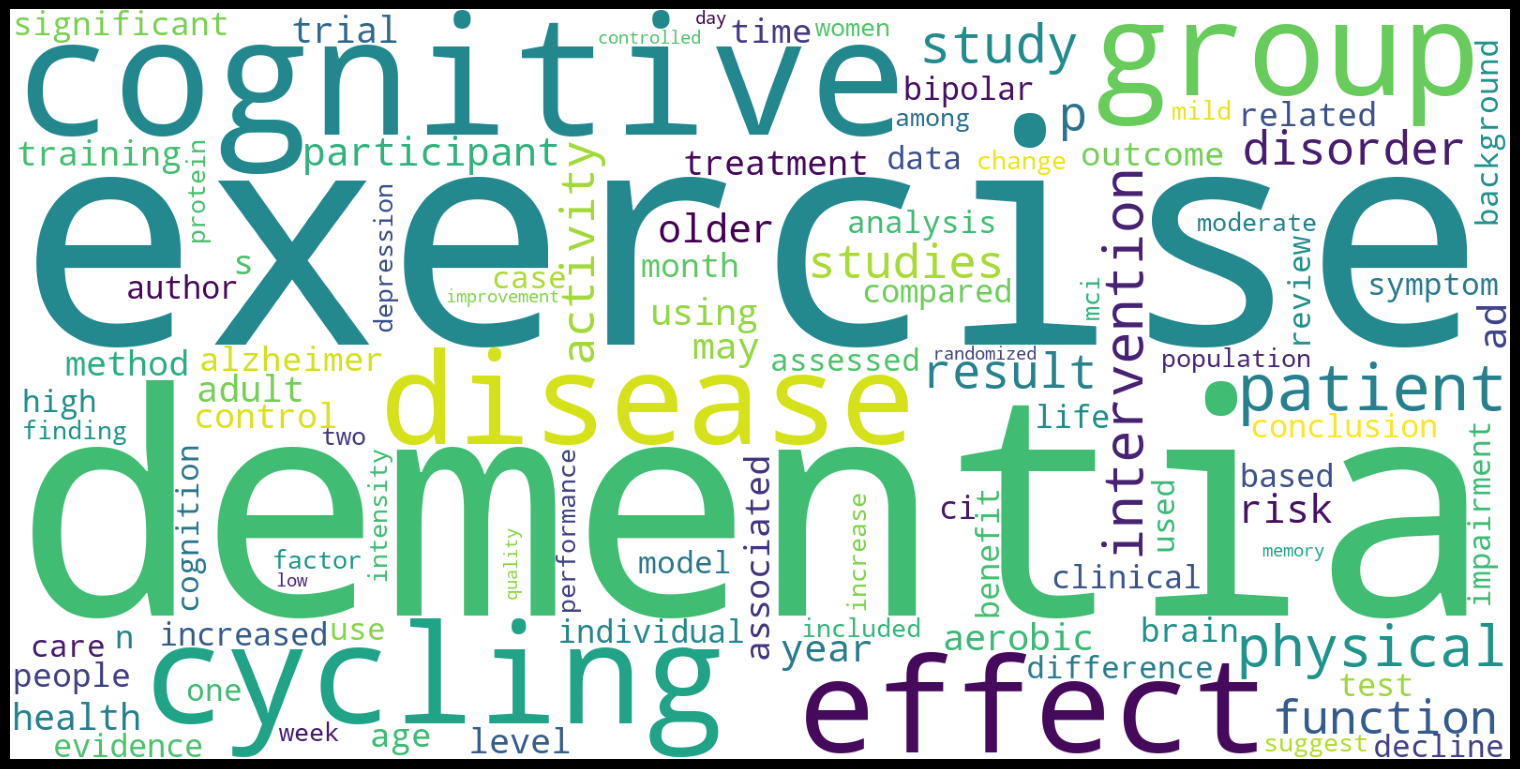

In [25]:
#### Most commonly used words in abstracts

bibfile.word_cloud_plot(entry = 'abs', size_x = 15, size_y = 10, wordsn = wordsn, rmv_custom_words = [])